# Naive Baseline 

In [ ]:
# Import Libraries
import pandas as pd
import numpy as nb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
# Load the raw appointment records CSV file into a pandas DataFrame
df= pd.read_csv(r'C:\Users\telvi\Downloads\AMDARI\nexora_care_flow\data\processed_data\AppointmentRecords_eda.csv')

In [5]:
# Display the first five rows to inspect the dataset structure and values
df.head()

,AppointmentID,ClinicID,ClinicName,ClinicType,PatientID,ProviderID,AppointmentDateTime,AppointmentType,Status,BookingChannel,BookingLeadTimeDays,IsHoliday,HolidayName,SeasonFlag,ChronicConditionFlag,DayOfWeek
0,529385,2,Nexora Care - Lakeside,Multi-Specialty,103642,202,2024-01-01 08:00:00,New Patient,Completed,Online,2,True,New Year's Day,Flu Season,False,Monday
1,500000,1,Nexora Care - Riverside,Primary Care,101551,101,2024-01-01 08:30:00,New Patient,No-Show,Online,18,True,New Year's Day,Flu Season,False,Monday
2,500011,1,Nexora Care - Riverside,Primary Care,100260,104,2024-01-01 08:30:00,Follow-Up,Completed,Referral,4,True,New Year's Day,Flu Season,False,Monday
3,575066,3,Nexora Care - Downtown Express,Telehealth-Forward,104923,301,2024-01-01 09:45:00,Urgent,Completed,Online,0,True,New Year's Day,Flu Season,False,Monday
4,500008,1,Nexora Care - Riverside,Primary Care,101124,104,2024-01-01 09:45:00,Telehealth,Completed,Phone,2,True,New Year's Day,Flu Season,False,Monday


In [ ]:
# Generate summary statistics for all numerical and categorical columns
df.describe(include = 'all')

,AppointmentID,ClinicID,ClinicName,ClinicType,PatientID,ProviderID,AppointmentDateTime,AppointmentType,Status,BookingChannel,BookingLeadTimeDays,IsHoliday,HolidayName,SeasonFlag,ChronicConditionFlag,DayOfWeek
count,129353.000000,129353.000000,129353,129353,129353.000000,129353.000000,129353,129353,129353,129353,129353.000000,129353,129353,129353,129353,129353
unique,NaN,NaN,4,3,NaN,NaN,30287,4,4,4,NaN,2,14,3,2,7
top,NaN,NaN,Nexora Care - Lakeside,Primary Care,NaN,NaN,2025-12-30 11:15:00,Follow-Up,Completed,Online,NaN,False,No Holiday,Standard,False,Tuesday
freq,NaN,NaN,45681,58526,NaN,NaN,19,57859,109040,57061,NaN,128414,128414,64015,92038,25350
mean,564676.000000,2.417864,NaN,NaN,103553.485385,245.290005,NaN,NaN,NaN,NaN,8.704267,NaN,NaN,NaN,NaN,NaN
std,37341.139023,1.071525,NaN,NaN,2020.941152,107.165883,NaN,NaN,NaN,NaN,7.641921,NaN,NaN,NaN,NaN,NaN
min,500000.000000,1.000000,NaN,NaN,100000.000000,101.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
25%,532338.000000,2.000000,NaN,NaN,101812.000000,201.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,NaN
50%,564676.000000,2.000000,NaN,NaN,103547.000000,205.000000,NaN,NaN,NaN,NaN,7.000000,NaN,NaN,NaN,NaN,NaN
75%,597014.000000,3.000000,NaN,NaN,105178.000000,306.000000,NaN,NaN,NaN,NaN,12.000000,NaN,NaN,NaN,NaN,NaN


In [7]:
# Display information about the DataFrame, including columns, data types, and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129353 entries, 0 to 129352
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   AppointmentID         129353 non-null  int64 
 1   ClinicID              129353 non-null  int64 
 2   ClinicName            129353 non-null  object
 3   ClinicType            129353 non-null  object
 4   PatientID             129353 non-null  int64 
 5   ProviderID            129353 non-null  int64 
 6   AppointmentDateTime   129353 non-null  object
 7   AppointmentType       129353 non-null  object
 8   Status                129353 non-null  object
 9   BookingChannel        129353 non-null  object
 10  BookingLeadTimeDays   129353 non-null  int64 
 11  IsHoliday             129353 non-null  bool  
 12  HolidayName           129353 non-null  object
 13  SeasonFlag            129353 non-null  object
 14  ChronicConditionFlag  129353 non-null  bool  
 15  DayOfWeek        

In [25]:
# AppointmentDateTime needs to be treated as a datetime variable
df['AppointmentDateTime'] = pd.to_datetime(df['AppointmentDateTime'])

In [15]:
# Check the data types to confirm the conversion
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129353 entries, 0 to 129352
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   AppointmentID         129353 non-null  int64         
 1   ClinicID              129353 non-null  int64         
 2   ClinicName            129353 non-null  object        
 3   ClinicType            129353 non-null  object        
 4   PatientID             129353 non-null  int64         
 5   ProviderID            129353 non-null  int64         
 6   AppointmentDateTime   129353 non-null  datetime64[ns]
 7   AppointmentType       129353 non-null  object        
 8   Status                129353 non-null  object        
 9   BookingChannel        129353 non-null  object        
 10  BookingLeadTimeDays   129353 non-null  int64         
 11  IsHoliday             129353 non-null  bool          
 12  HolidayName           129353 non-null  object        
 13 

In [12]:
#verify if data type of the AppointmentDateTime column has changed to datetype 
df['AppointmentDateTime'].dtype

dtype('<M8[ns]')

In [13]:
df.isnull().sum()

AppointmentID           0
ClinicID                0
ClinicName              0
ClinicType              0
PatientID               0
ProviderID              0
AppointmentDateTime     0
AppointmentType         0
Status                  0
BookingChannel          0
BookingLeadTimeDays     0
IsHoliday               0
HolidayName             0
SeasonFlag              0
ChronicConditionFlag    0
DayOfWeek               0
dtype: int64

In [33]:
# Count the number of appointments that occurred each day.
# .dt.date removes the time and keeps only the date.
daily_appointment = (
    df.groupby(df["AppointmentDateTime"].dt.date)
      .size()
      .reset_index(name="AppointmentVolume")
)

# Set AppointmentDateTime as the index.
# asfreq("D") ensures that we have one row for every day.
# If a day has no appointments, AppointmentVolume becomes 0.
daily_appointment = (
    daily_appointment
    .set_index("AppointmentDateTime")
    .asfreq("D", fill_value=0)
)
# Create a daily holiday indicator.
# .first() means that if ANY appointment on that day
# is marked as a holiday, the whole day is treated as a holiday.
holiday_daily_appointment = (
    df.groupby(df["AppointmentDateTime"].dt.date)["IsHoliday"]
      .first()
)
# Add the holiday indicator to our daily appointment dataset.
# 1 = Holiday
# 0 = Not a holiday
daily_appointment["IsHoliday"] = (
    holiday_daily_appointment
    .reindex(
        daily_appointment.index,
        fill_value=0
    )
    .astype(int)
)

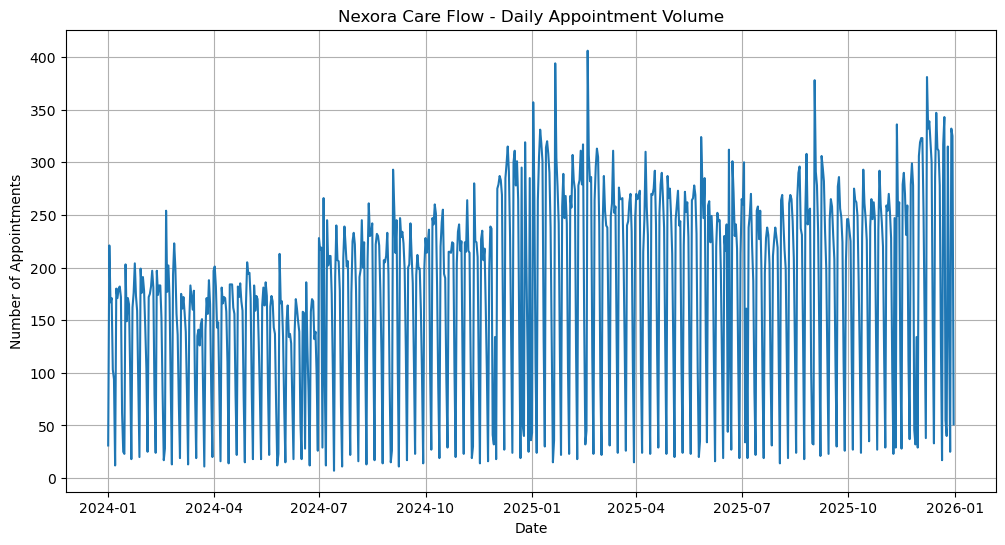

In [34]:
# Plot daily appointment volume over time
plt.figure(figsize=(12, 6))

# Plot the appointment volume for each day
plt.plot(
    daily_appointment.index,
    daily_appointment["AppointmentVolume"]
)

# Add a title to the plot
plt.title("Nexora Care Flow - Daily Appointment Volume")

# Label the x-axis
plt.xlabel("Date")

# Label the y-axis
plt.ylabel("Number of Appointments")

# Add gridlines to make the values easier to read
plt.grid(True)

# Display the plot
plt.show()

Time Based Term / Train Split

In [35]:
# test_weeks = 8 → you want to test the model over 8 weeks
# 7 → there are 7 days in a week
# test_size = 56 → 8 × 7 = 56 days

# Number of weeks to use for testing
test_weeks = 8

# Convert the number of test weeks into number of days
test_size = test_weeks * 7

# Use all observations except the final 56 days for training
train = daily_appointment.iloc[:-test_size]

# Use the final 56 days for testing
test = daily_appointment.iloc[-test_size:]

# Check the size of each dataset
print("Training observations:", len(train))
print("Testing observations:", len(test))

# Check the date ranges
print("\nTraining period:")
print(train.index.min(),  train.index.max())

print("\nTesting period:")
print(test.index.min(), test.index.max())

Training observations: 675
Testing observations: 56

Training period:
2024-01-01 00:00:00 2025-11-05 00:00:00

Testing period:
2025-11-06 00:00:00 2025-12-31 00:00:00


In [37]:
# Seasonal naive baseline
# Predict today's appointment volume using the volume
# from 7 days ago (same day of the previous week)
naive_seasonal_baseline = (
    daily_appointment["AppointmentVolume"]
    .shift(7)
    .loc[test.index]
)